# AE Aur and $\mu$ Col 
AE Aur 182071570715713024
mu col 2901155648586891648

In [1]:
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
from astropy.table import Column, join, Table, vstack, hstack
from astropy.io import ascii
import astropy.coordinates as coords
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style

import emcee
import corner
from datetime import datetime
import os
from astropy.io.votable import parse

In [2]:
from Galactic_traceback import GalacticTraceback
from HMXB_pipeline_class import pipeline
from Galactic_traceback_for_MCMC import galactic_path_MCMC as gpMCMC

In [3]:
cwd = os.getcwd()
today = datetime.now().strftime("%Y%m%d")
home_files = os.path.dirname(cwd)
home_files = home_files + '/'
csv_files  = home_files + 'DATA/'
csv_files

'/home/karan/Documents/UvA/Thesis/DATA/'

In [45]:
ori_case = ascii.read(csv_files+'Orion_test_case-result.ecsv',format='ecsv')
iota_ori = ascii.read(csv_files+'Iota Ori-result.ecsv',format='ecsv')

In [57]:
ori_case

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
182071570715713024,79.07559666990984,0.03253635,34.31251139077335,0.021343945,-4.74655801090574,0.04624765,43.53767238272993,0.03277261,172.08114110834472,-2.259140767320703,2.573988882528692,0.033972435,--,--,-0.14975126,-0.0010803483,-0.0281311,0.31334937,-0.10558603,0.39656842,-0.33576027,-0.05332556,0.2632448,-0.4346779
2901155648586891648,86.4995797980886,0.06557079,-32.306532522642556,0.08035317,3.2706512522056697,0.09479073,-22.176232095473445,0.11003597,237.28627063651672,-27.102090530633735,1.7024424209158613,0.08977867,--,--,-0.016671812,0.13365124,0.1080637,-0.03312972,0.08346912,-0.026186056,0.13618559,0.21209313,0.057225637,-0.06599678


In [52]:
ori_bj = ascii.read(csv_files+'Ori_stars_bj.csv',format='csv')
iota_bj  = ascii.read(csv_files+'Iota_ori_BJ.csv',format='csv')
ori_bj

iota_bj['r_med_photogeo'] = iota_bj['r_med_photogeo']/1000
iota_bj['r_med_photogeo'].unit = u.kpc

iota_bj['r_hi_photogeo'] = iota_bj['r_hi_photogeo']/1000
iota_bj['r_hi_photogeo'].unit = u.kpc

iota_bj['r_lo_photogeo'] = iota_bj['r_lo_photogeo']/1000
iota_bj['r_lo_photogeo'].unit = u.kpc

ori_bj['r_med_photogeo'] = ori_bj['r_med_photogeo']/1000
ori_bj['r_med_photogeo'].unit = u.kpc

ori_bj['r_hi_photogeo'] = ori_bj['r_hi_photogeo']/1000
ori_bj['r_hi_photogeo'].unit = u.kpc

ori_bj['r_lo_photogeo'] = ori_bj['r_lo_photogeo']/1000
ori_bj['r_lo_photogeo'].unit = u.kpc
ori_bj.rename_columns(['r_med_photogeo', 'r_lo_photogeo', 'r_hi_photogeo'], ['distance_bj','distance_bj_low','distance_bj_high'])

iota_bj.rename_columns(['r_med_photogeo', 'r_lo_photogeo', 'r_hi_photogeo'], ['distance_bj','distance_bj_low','distance_bj_high'])

In [53]:
iota_bj

source_id,distance_bj,distance_bj_low,distance_bj_high
,kpc,kpc,kpc
int64,float64,float64,float64
3017190546641718144,0.6972429,0.48314389999999996,1.0763082


In [8]:
ori_case = join(ori_case,ori_bj,keys='source_id',join_type='left')

In [55]:
iota_ori = join(iota_ori, iota_bj, keys='source_id',join_type='left')

In [56]:
iota_ori

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64
3017190546641718144,83.85826322361507,0.564689,-5.909896048091421,0.48135543,-2.81577187123059,1.022422,-1.69303154943788,0.8332572,209.52210609496424,-19.58346006748752,1.9968658285610956,0.7299109,--,--,0.5664461,-0.1161991,-0.35833615,-0.51261276,-0.08616136,-0.48172742,-0.4493435,-0.023226311,0.23755918,0.6318202,0.6972429,0.48314389999999996,1.0763082


In [9]:
ori_case

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64
182071570715713024,79.07559666990984,0.03253635,34.31251139077335,0.021343945,-4.74655801090574,0.04624765,43.53767238272993,0.03277261,172.08114110834472,-2.259140767320703,2.573988882528692,0.033972435,--,--,-0.14975126,-0.0010803483,-0.0281311,0.31334937,-0.10558603,0.39656842,-0.33576027,-0.05332556,0.2632448,-0.4346779,0.38020044000000003,0.3752654,0.38476196
2901155648586891648,86.4995797980886,0.06557079,-32.306532522642556,0.08035317,3.2706512522056697,0.09479073,-22.176232095473445,0.11003597,237.28627063651672,-27.102090530633735,1.7024424209158613,0.08977867,--,--,-0.016671812,0.13365124,0.1080637,-0.03312972,0.08346912,-0.026186056,0.13618559,0.21209313,0.057225637,-0.06599678,0.5847863,0.5549753399999999,0.62287134


# Add RV and Name

RV for AE AUR 
https://simbad.cds.unistra.fr/simbad/sim-ref?bibcode=2023ApJS..266...41P

For mu COl
https://simbad.cds.unistra.fr/simbad/sim-ref?bibcode=2018A%26A...613A..65H

In [58]:
tab = Table(
    names=('source_id','RV', 'RV_err', 'Name','Mod_SpType'),
    data=[[182071570715713024,2901155648586891648],[56.7, 106] * u.km/u.s, [0.6,5.0]*u.km/u.s,
          ['AE Aur', r'$\mu$ Col'],['xkcd:blue','xkcd:purple']]
)
tab

iota_cols = Table(
    names=('source_id','RV', 'RV_err', 'Name','Mod_SpType'),
    data=[[3017190546641718144],[27.60] * u.km/u.s, [0.3]*u.km/u.s,
          ['Iota Ori'],['xkcd:red']]
)

In [11]:
ori_case = join(ori_case, tab, keys='source_id',join_type='left')

In [59]:
iota_ori = join(iota_ori, iota_cols,keys='source_id',join_type='left')

In [63]:
# iota_ori.write(csv_files+'iota_ori_for_pipeline.ecsv',format='ascii.ecsv',overwrite=True)
# HMXB_pipeline = pipeline(csv_files+'iota_ori_for_pipeline.ecsv', fmt='ecsv')
# iota_table = HMXB_pipeline.lay_pipe(filename=csv_files+f'iota_table_{today}.ecsv',filetype='ascii.ecsv')

In [64]:
iota_table

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str8,str8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
3017190546641718144,83.85826322361507,0.564689,-5.909896048091421,0.48135543,-2.81577187123059,1.022422,-1.69303154943788,0.8332572,209.52210609496424,-19.58346006748752,1.9968658285610956,0.7299109,--,--,0.5664461,-0.1161991,-0.35833615,-0.51261276,-0.08616136,-0.48172742,-0.4493435,-0.023226311,0.23755918,0.6318202,0.6972429,0.48314389999999996,1.0763082,27.6,0.3,Iota Ori,xkcd:red,0.5007847726657636,0.23123917132424449,-3.2774159796783082,8.72762571964018,240.13290186005702,-103.10798407470725,1.9705256521359578,-0.5338113843051325,17.715403810228995,-2.5182440751621287,0.587700150112501,5.846570272658297,11.30671365339882,4.038025917112709,0.7789575943504154,-3.3313047454856766,12.006141218027931,0.18305099119197143


In [12]:
# ori_case.write(csv_files+'ori_case_for_pipeline.ecsv',format='ascii.ecsv',overwrite=True)
# HMXB_pipeline = pipeline(csv_files+'ori_case_for_pipeline.ecsv', fmt='ecsv')
# ori_table = HMXB_pipeline.lay_pipe(filename=csv_files+f'ori_table_{today}.ecsv',filetype='ascii.ecsv')

# Add errors

In [65]:
orion_vpec_errors = ascii.read(csv_files+'orion_v_pec_errors.ecsv',format='ecsv')
orion_jacobian = ascii.read(csv_files+'orion_jacobian.ecsv',format='ecsv')

iota_vpec_errors = ascii.read(csv_files+'iota_v_pec_errors.ecsv',format='ecsv')
iota_jacobian = ascii.read(csv_files+'iota_jacobian.ecsv',format='ecsv')

In [66]:
iota_jacobian

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str8,str8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
3017190546641718144,83.85826322361507,0.564689,-5.909896048091421,0.48135543,-2.81577187123059,1.022422,-1.69303154943788,0.8332572,209.52210609496424,-19.58346006748752,1.9968658285610956,0.7299109,--,--,0.5664461,-0.1161991,-0.35833615,-0.51261276,-0.08616136,-0.48172742,-0.4493435,-0.023226311,0.23755918,0.6318202,0.6972429,0.48314389999999996,1.0763082,27.6,0.3,Iota Ori,xkcd:red,0.5007847726657636,0.23123917132424449,-3.2774159796783082,8.72762571964018,240.13290186005702,-103.10798407470725,1.9705256521359578,-0.5338113843051325,17.715403810228995,-2.5182440751621287,0.587700150112501,5.846570272658297,11.30671365339882,4.038025917112709,0.7789575943504154,-3.3313047454856766,12.006141218027931,0.18305099119197143,0.4419583024224686,0.2688280218423748,0.7690260077157971,0.47759896607344426


In [14]:
ori_case = join(orion_jacobian, orion_vpec_errors,keys='source_id', join_type='left')

In [15]:
orion_jacobian

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str9,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
182071570715713024,79.07559666990984,0.03253635,34.31251139077335,0.021343945,-4.74655801090574,0.04624765,43.53767238272993,0.03277261,172.08114110834472,-2.259140767320703,2.573988882528692,0.033972435,--,--,-0.14975126,-0.0010803483,-0.0281311,0.31334937,-0.10558603,0.39656842,-0.33576027,-0.05332556,0.2632448,-0.4346779,0.38020044000000003,0.3752654,0.38476196,56.7,0.6,AE Aur,xkcd:blue,0.3885020664959508,-38.28986996531914,21.258988393048448,8.526442869755808,239.913899974291,31.27369291617289,8.300215905982963,-4.020910377658974,9.116061647832543,-2.2629453641851103,-0.020125200123173502,-0.9618240607414603,91.9800631688847,48.54576241290892,-44.327140507117,25.300023970830598,104.0049184837074,0.005127590555753349,0.024861150656174388,0.012253224284901306,0.04070956157861264,0.020246659273163506
2901155648586891648,86.4995797980886,0.06557079,-32.306532522642556,0.08035317,3.2706512522056697,0.09479073,-22.176232095473445,0.11003597,237.28627063651672,-27.102090530633735,1.7024424209158613,0.08977867,--,--,-0.016671812,0.13365124,0.1080637,-0.03312972,0.08346912,-0.026186056,0.13618559,0.21209313,0.057225637,-0.06599678,0.5847863,0.5549753399999999,0.62287134,106.0,5.0,$\mu$ Col,xkcd:purple,0.5873913782423437,22.167345398679128,-3.3303494623718244,8.442709575745095,239.82128391201022,-171.78928740365626,-0.6266155600193664,0.39925337664971833,18.844585424737467,-5.008627677047539,0.6213683481048637,3.486361902645862,78.00362476464818,83.66905267261666,27.802588635746034,-4.350971187126406,114.39001639809803,0.030976211340612816,0.07228656888371544,0.02339611835779219,0.09800312232857962,0.03185214005330146


In [16]:
Trapezium = Table([['Orion'],[0.450]*u.kpc, [209.0]*u.deg, [-19.4]*u.deg, [2.0]*u.mas/u.yr, [2.0]*u.mas/u.yr, [24]*u.km/u.s,['xkcd:grey']],
                        names=["Name", "distance_bj", "l", "b", "pm_l_poleski", "pm_b_poleski", "RV",'Mod_SpType'])


In [17]:
Trapezium

Name,distance_bj,l,b,pm_l_poleski,pm_b_poleski,RV,Mod_SpType
,kpc,deg,deg,mas / yr,mas / yr,km / s,
str5,float64,float64,float64,float64,float64,float64,str9
Orion,0.45,209.0,-19.4,2.0,2.0,24.0,xkcd:grey


In [18]:
AeAur = Table(orion_jacobian[0])
mucol = Table(orion_jacobian[1])

In [19]:
mucol

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str9,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2901155648586891648,86.4995797980886,0.06557079,-32.306532522642556,0.08035317,3.2706512522056697,0.09479073,-22.176232095473445,0.11003597,237.28627063651672,-27.102090530633735,1.7024424209158613,0.08977867,--,--,-0.016671812,0.13365124,0.1080637,-0.03312972,0.08346912,-0.026186056,0.13618559,0.21209313,0.057225637,-0.06599678,0.5847863,0.5549753399999999,0.62287134,106.0,5.0,$\mu$ Col,xkcd:purple,0.5873913782423437,22.167345398679128,-3.3303494623718244,8.442709575745095,239.82128391201022,-171.78928740365626,-0.6266155600193664,0.39925337664971833,18.844585424737467,-5.008627677047539,0.6213683481048637,3.486361902645862,78.00362476464818,83.66905267261666,27.802588635746034,-4.350971187126406,114.39001639809803,0.030976211340612816,0.07228656888371544,0.02339611835779219,0.09800312232857962,0.03185214005330146


In [20]:
new_table = vstack([orion_jacobian, Trapezium])
new_table

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str9,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
182071570715713024,79.07559666990984,0.03253635,34.31251139077335,0.021343945,-4.74655801090574,0.04624765,43.53767238272993,0.03277261,172.08114110834472,-2.259140767320703,2.573988882528692,0.033972435,--,--,-0.14975126,-0.0010803483,-0.0281311,0.31334937,-0.10558603,0.39656842,-0.33576027,-0.05332556,0.2632448,-0.4346779,0.38020044000000003,0.3752654,0.38476196,56.7,0.6,AE Aur,xkcd:blue,0.3885020664959508,-38.28986996531914,21.258988393048448,8.526442869755808,239.913899974291,31.27369291617289,8.300215905982963,-4.020910377658974,9.116061647832543,-2.2629453641851103,-0.020125200123173502,-0.9618240607414603,91.9800631688847,48.54576241290892,-44.327140507117,25.300023970830598,104.0049184837074,0.005127590555753349,0.024861150656174388,0.012253224284901306,0.04070956157861264,0.020246659273163506
2901155648586891648,86.4995797980886,0.06557079,-32.306532522642556,0.08035317,3.2706512522056697,0.09479073,-22.176232095473445,0.11003597,237.28627063651672,-27.102090530633735,1.7024424209158613,0.08977867,--,--,-0.016671812,0.13365124,0.1080637,-0.03312972,0.08346912,-0.026186056,0.13618559,0.21209313,0.057225637,-0.06599678,0.5847863,0.5549753399999999,0.62287134,106.0,5.0,$\mu$ Col,xkcd:purple,0.5873913782423437,22.167345398679128,-3.3303494623718244,8.442709575745095,239.82128391201022,-171.78928740365626,-0.6266155600193664,0.39925337664971833,18.844585424737467,-5.008627677047539,0.6213683481048637,3.486361902645862,78.00362476464818,83.66905267261666,27.802588635746034,-4.350971187126406,114.39001639809803,0.030976211340612816,0.07228656888371544,0.02339611835779219,0.09800312232857962,0.03185214005330146
--,--,--,--,--,--,--,--,--,209.0,-19.4,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.45,--,--,24.0,--,Orion,xkcd:grey,--,2.0,2.0,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--


In [21]:
AeAur

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str9,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
182071570715713024,79.07559666990984,0.03253635,34.31251139077335,0.021343945,-4.74655801090574,0.04624765,43.53767238272993,0.03277261,172.08114110834472,-2.259140767320703,2.573988882528692,0.033972435,--,--,-0.14975126,-0.0010803483,-0.0281311,0.31334937,-0.10558603,0.39656842,-0.33576027,-0.05332556,0.2632448,-0.4346779,0.38020044000000003,0.3752654,0.38476196,56.7,0.6,AE Aur,xkcd:blue,0.3885020664959508,-38.28986996531914,21.258988393048448,8.526442869755808,239.913899974291,31.27369291617289,8.300215905982963,-4.020910377658974,9.116061647832543,-2.2629453641851103,-0.020125200123173502,-0.9618240607414603,91.9800631688847,48.54576241290892,-44.327140507117,25.300023970830598,104.0049184837074,0.005127590555753349,0.024861150656174388,0.012253224284901306,0.04070956157861264,0.020246659273163506


In [22]:
mucol

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str9,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2901155648586891648,86.4995797980886,0.06557079,-32.306532522642556,0.08035317,3.2706512522056697,0.09479073,-22.176232095473445,0.11003597,237.28627063651672,-27.102090530633735,1.7024424209158613,0.08977867,--,--,-0.016671812,0.13365124,0.1080637,-0.03312972,0.08346912,-0.026186056,0.13618559,0.21209313,0.057225637,-0.06599678,0.5847863,0.5549753399999999,0.62287134,106.0,5.0,$\mu$ Col,xkcd:purple,0.5873913782423437,22.167345398679128,-3.3303494623718244,8.442709575745095,239.82128391201022,-171.78928740365626,-0.6266155600193664,0.39925337664971833,18.844585424737467,-5.008627677047539,0.6213683481048637,3.486361902645862,78.00362476464818,83.66905267261666,27.802588635746034,-4.350971187126406,114.39001639809803,0.030976211340612816,0.07228656888371544,0.02339611835779219,0.09800312232857962,0.03185214005330146


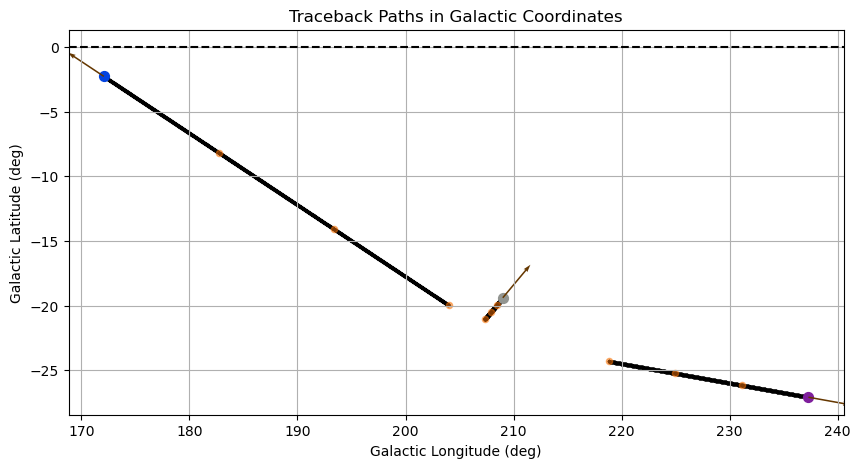

In [23]:
AeAur
#.plot_with_cluster(clustername='NGC 6231',cluster_params=ngc6231_params, clustertable=ngc6231_members,savefig=False)
GalacticTraceback(new_table, -3.0).plot_trace(savefig=True)#plot_with_cluster('Trapesium',Trapezium,clustertable=None,savefig=False)

In [24]:
mucol['pm_l_poleski']

22.167345398679128


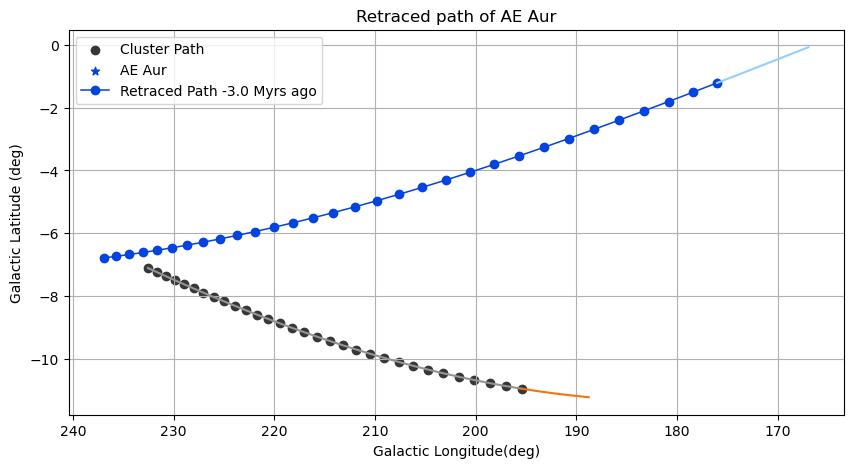

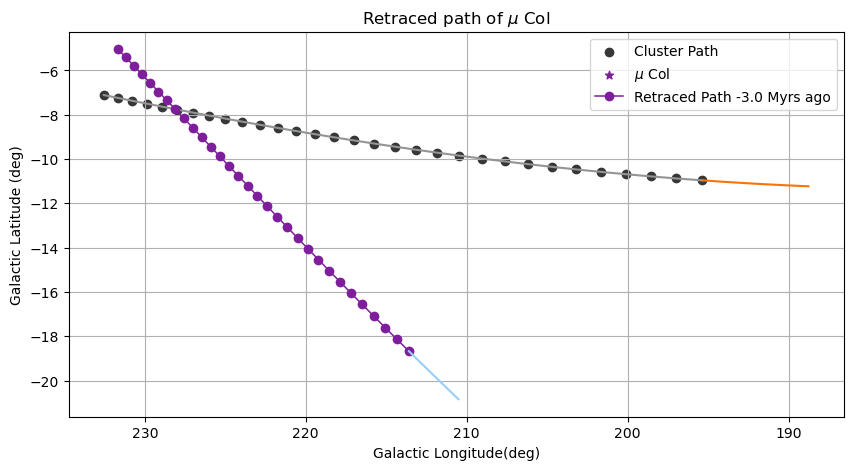

In [25]:
for star in orion_jacobian:
    GalacticTraceback(Table(star),-3.0).plot_with_cluster(clustername='Orion',cluster_params=Trapezium,clustertable=None,savefig=True)

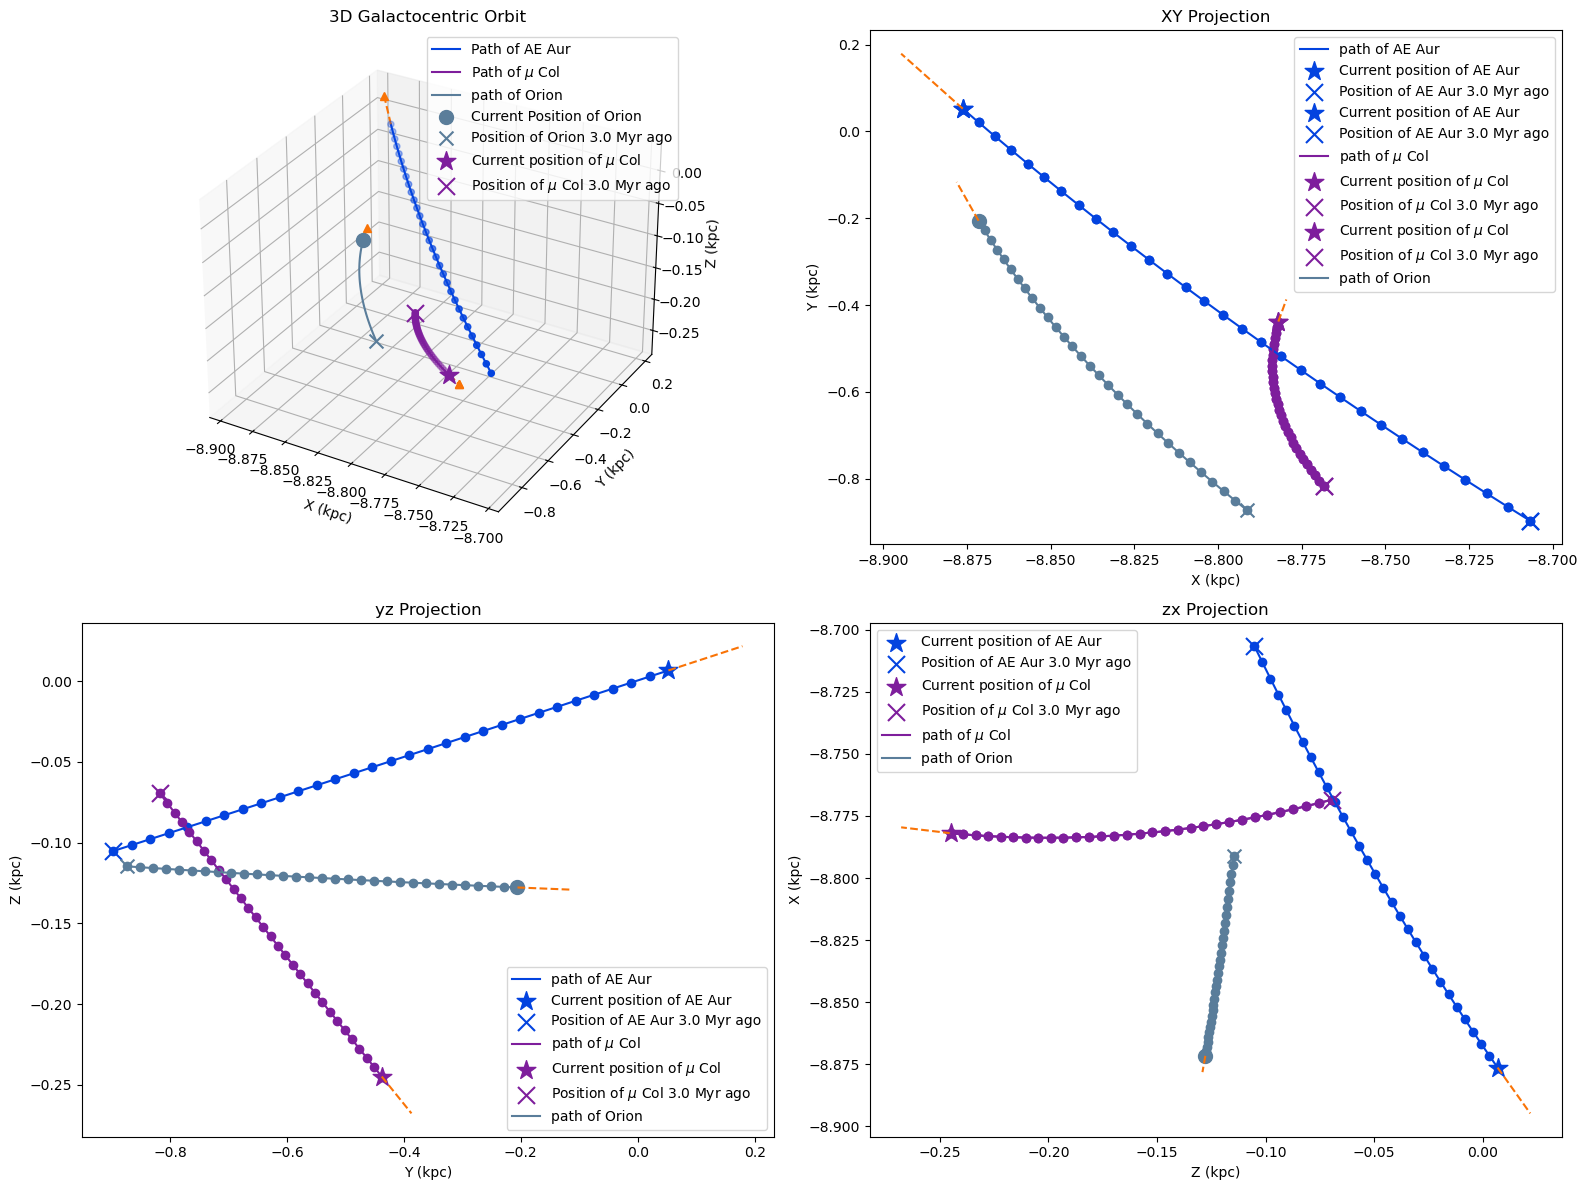

In [26]:
GalacticTraceback(mucol, -3.0).plot_in_galactocentric(orion_jacobian, Trapezium,figname='test',cluster_members=None,savefig=False)

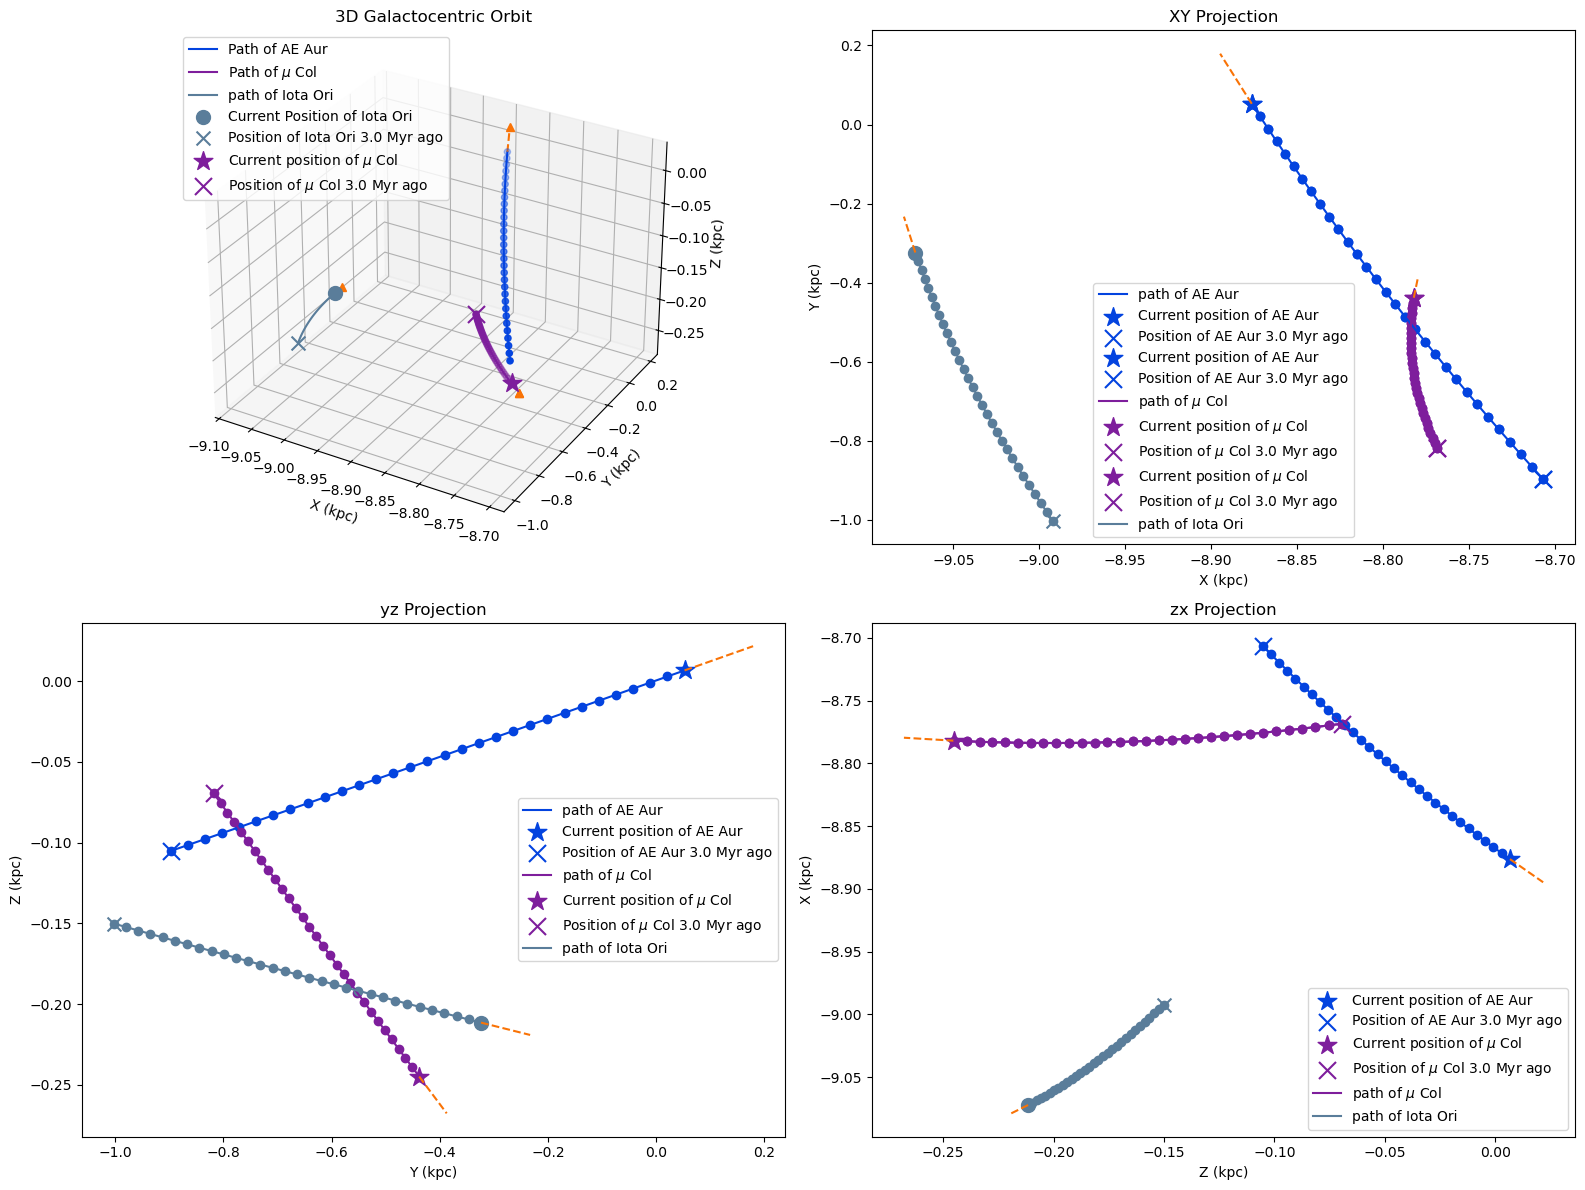

In [67]:
GalacticTraceback(None, -3.0).plot_in_galactocentric(orion_jacobian,iota_jacobian,figname='iota',cluster_members=None,savefig=True)

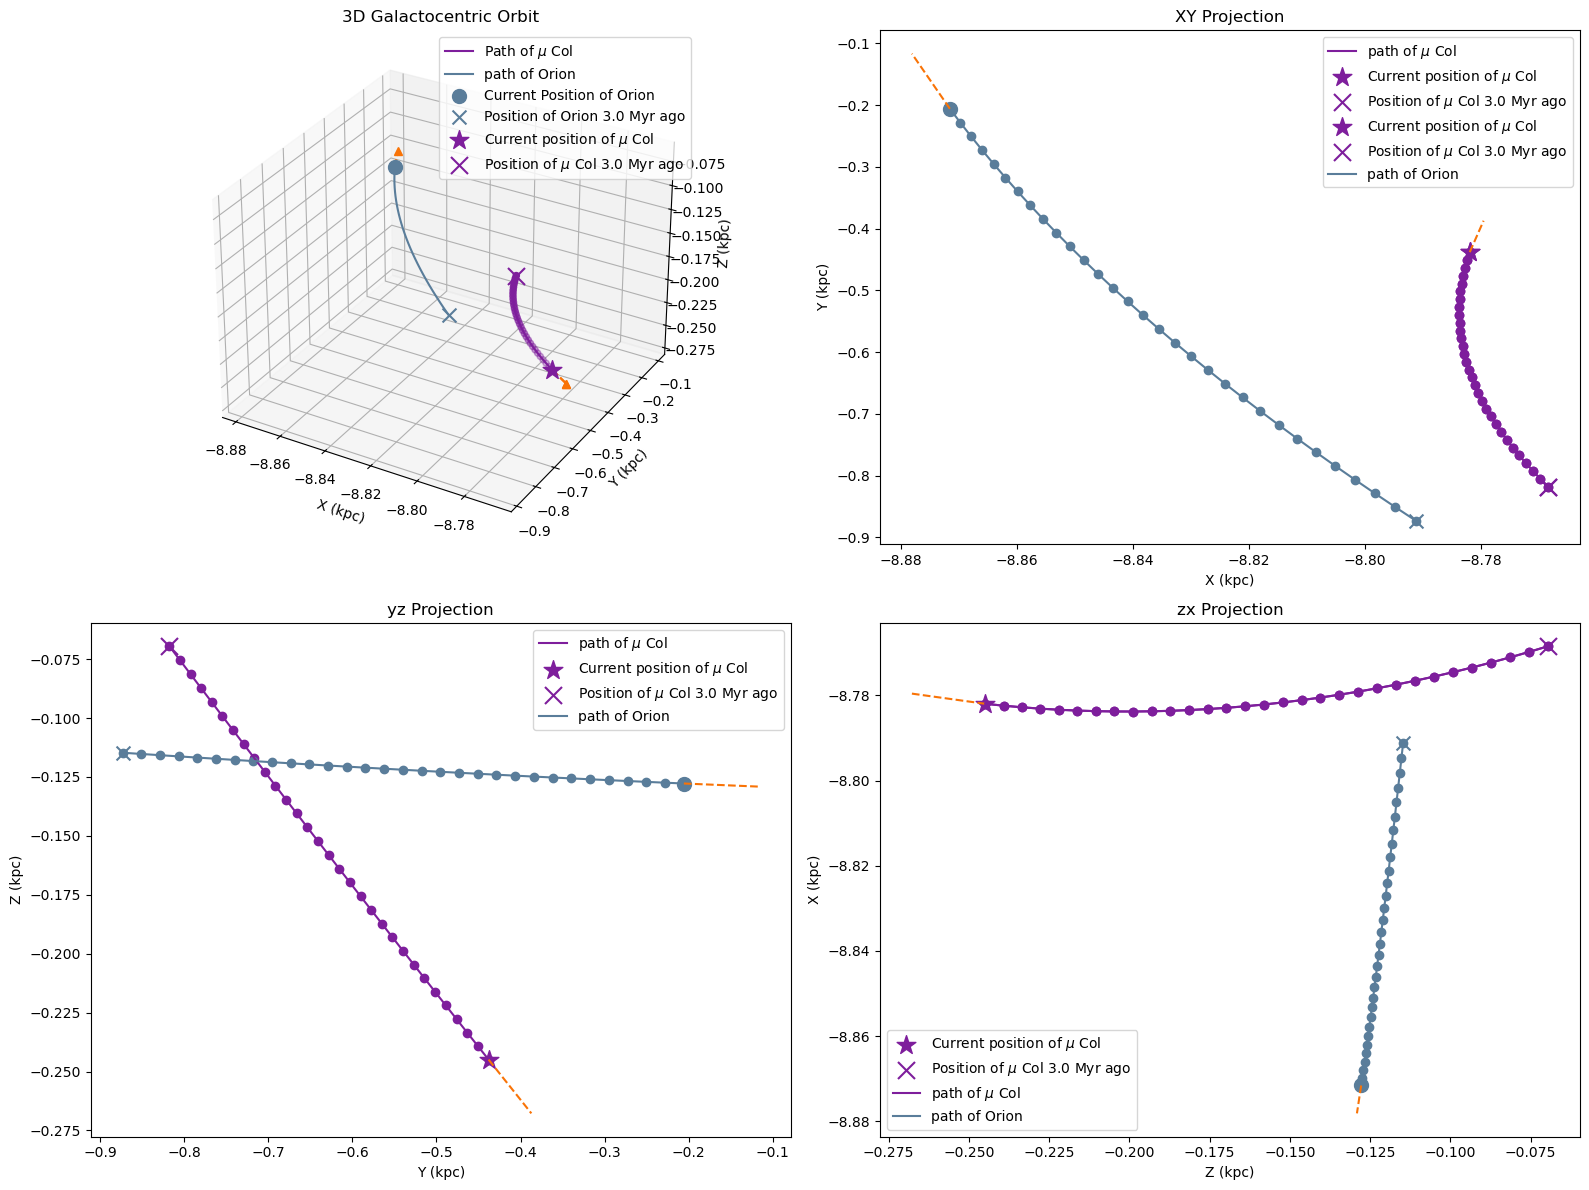

In [27]:
#plot_in_galactocentric(test_170037, ngc6231_params,cluster_members=ngc6231_members,savefig=True)
GalacticTraceback(mucol, -3.0).plot_in_galactocentric(mucol,Trapezium,figname='mu_col_orion', cluster_members=None,savefig=True)

# for star in ori_table:
#     GalacticTraceback(Table(star), -3.0).plot_in_galactocentric(Table(star),Trapezium,None,savefig=True)

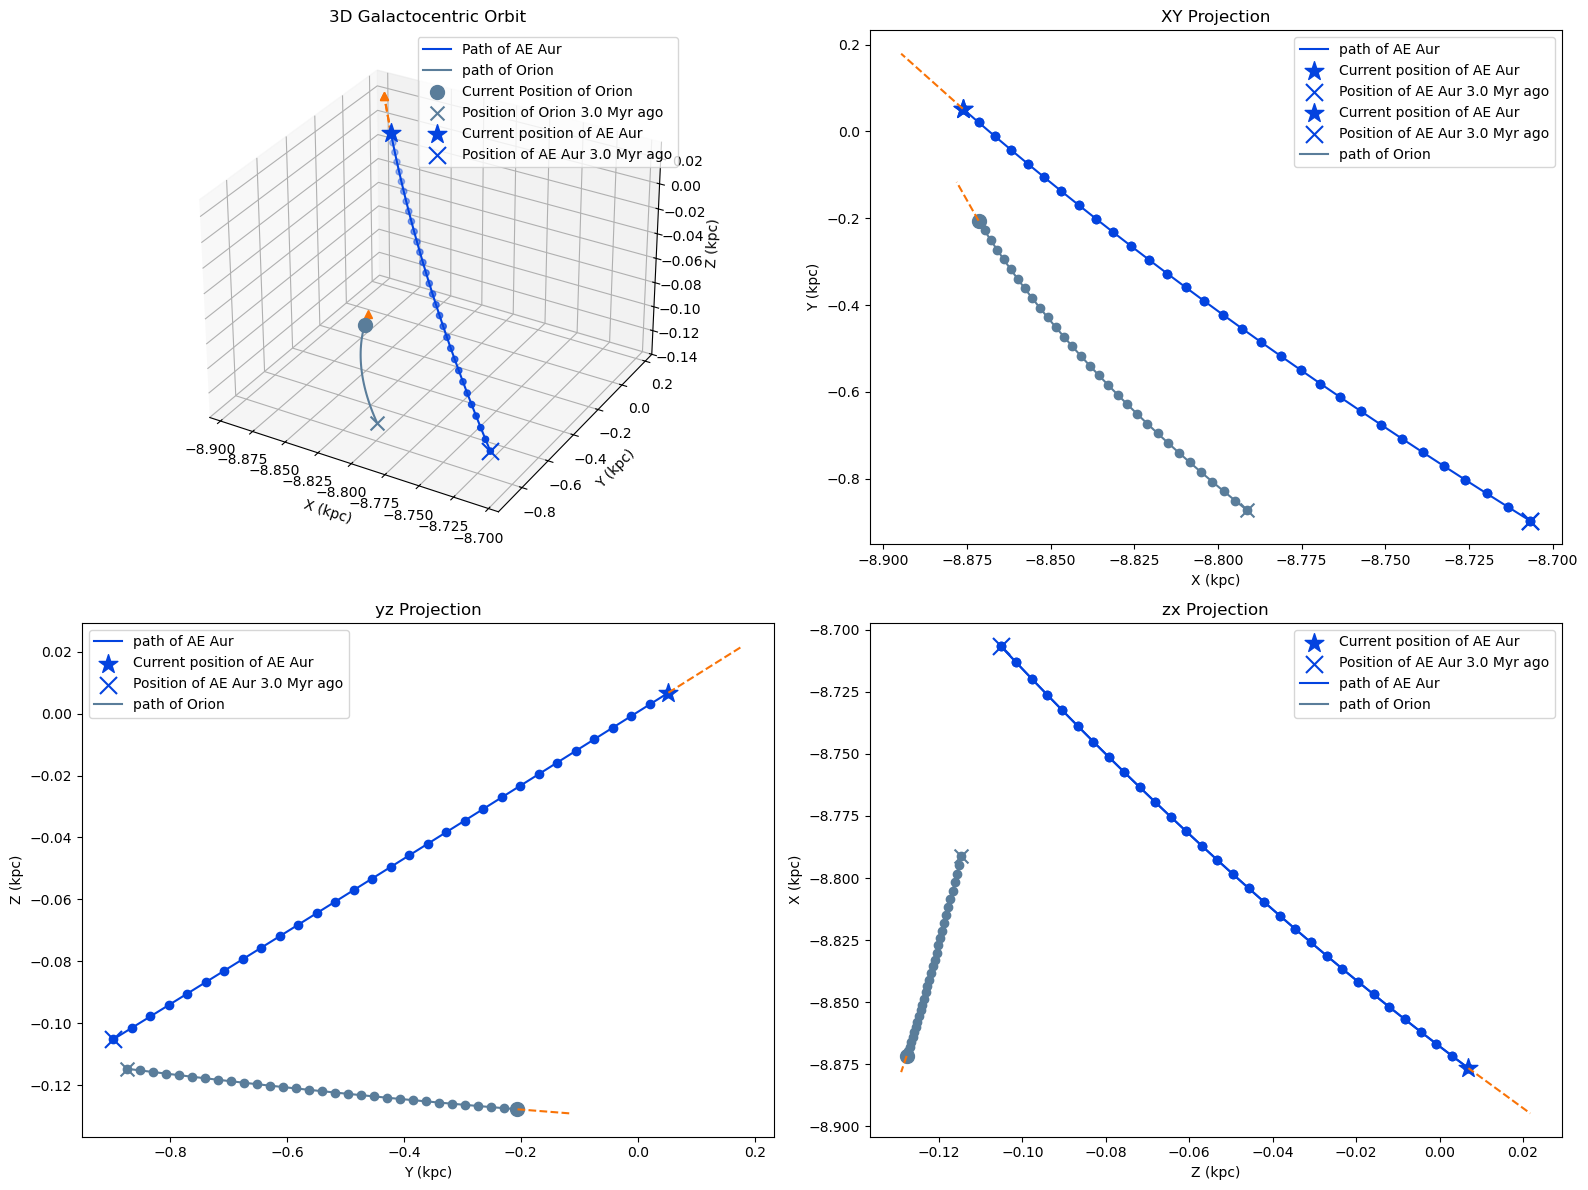

In [28]:
GalacticTraceback(mucol, -3.0).plot_in_galactocentric(AeAur,Trapezium,figname='AE_AUR_Orion', cluster_members=None,savefig=True)

In [29]:
#GalacticTraceback(ori_table, -3.0).plot_in_galactocentric(ori_table,Trapezium,None,savefig=False)

In [30]:
names_x = ['mu_col', 'Trapezium']
gpmc_args = {'backend_name':'mucol_trapezium_chain','star_params':mucol,'cluster_params':Trapezium, 'cluster_radius':10,'int_time':-5.0,
            'names':names_x}




# MCMC for $\mu Col$ and Trapezium 

In [31]:
#sample_x, state_X = gpMCMC().start_mcmc(**gpmc_args)

In [32]:
backend_x = emcee.backends.HDFBackend('mucol_trapezium_chain.h5')

In [33]:
samples_x = backend_x.get_chain(thin=10, flat=True)
blobs_x = backend_x.get_blobs(thin=10,flat=True)
kinematic_ages = np.array([b[0] for b in blobs_x])
min_separations = np.array([b[1] for b in blobs_x])

In [34]:
min_separations

array([0.05676245, 0.02092395, 0.08531342, ..., 0.01162219, 0.08210857,
       0.04398587])

In [35]:

def corner_with_filter(flat_chain, flat_blobs, cluster_radius_pc):
    """
    Makes an overlaid corner plot for MCMC samples:
    - All samples (gray)
    - Samples with min_sep < cluster_radius (red)
    
    Parameters
    ----------
    flat_chain : ndarray
        MCMC samples, shape (n_samples, 4), columns = [distance, pml, pmb, RV].
    flat_blobs : ndarray
        MCMC blobs, shape (n_samples, 2), columns = [kin_age, min_sep].
    cluster_radius_pc : float
        Radius of the cluster in parsecs.
    """
    
    # Extract min_sep from blobs
    min_seps = flat_blobs[:, 1]
    
    # Filter mask
    mask = min_seps*1000 < cluster_radius_pc
    filtered_chain = flat_chain[mask]
    print(len(flat_chain))
    print(len(filtered_chain))
    
    # Axis labels
    labels = [r"$d\ (\mathrm{kpc})$", 
              r"$\mu_\ell\ (\mathrm{mas/yr})$", 
              r"$\mu_b\ (\mathrm{mas/yr})$", 
              r"$v_r\ (\mathrm{km/s})$"]
    
    # Corner plot: all samples (gray)
    fig = corner.corner(
        flat_chain, labels=labels, color='gray',
        bins=30, plot_density=False, fill_contours=False,
        levels=(0.68, 0.95), label_kwargs={"fontsize": 13}
    )
    
    # Overlay filtered samples (red)
    corner.corner(
        filtered_chain, labels=labels, color='xkcd:purple',
        bins=30, plot_density=True, fill_contours=False,
        levels=(0.68, 0.95), fig=fig
    )
    
    # Manual legend
    ax0 = plt.gcf().axes[0]
    ax0.text(0.95, 0.95, "All samples", color='gray', fontsize=12,
             ha='right', va='top', transform=ax0.transAxes)
    ax0.text(0.95, 0.85, r"Filtered: $r_{\rm min} < R_{\rm cl}$", color='xkcd:purple',
             fontsize=12, ha='right', va='top', transform=ax0.transAxes)
    
    plt.show()

7200
[[2.4]
 [2.6]
 [2.2]
 ...
 [2.7]
 [2.2]
 [2.4]]


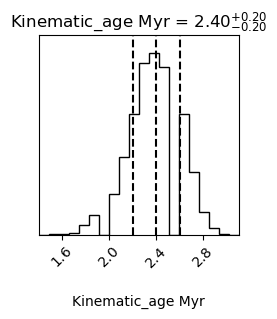

In [36]:
blobs_2d = kinematic_ages[:, None]  # reshape to (n_samples, 1)
print(len(blobs_2d))
print(blobs_2d)
fig = corner.corner(blobs_2d, labels=["Kinematic_age Myr"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)

7200
680


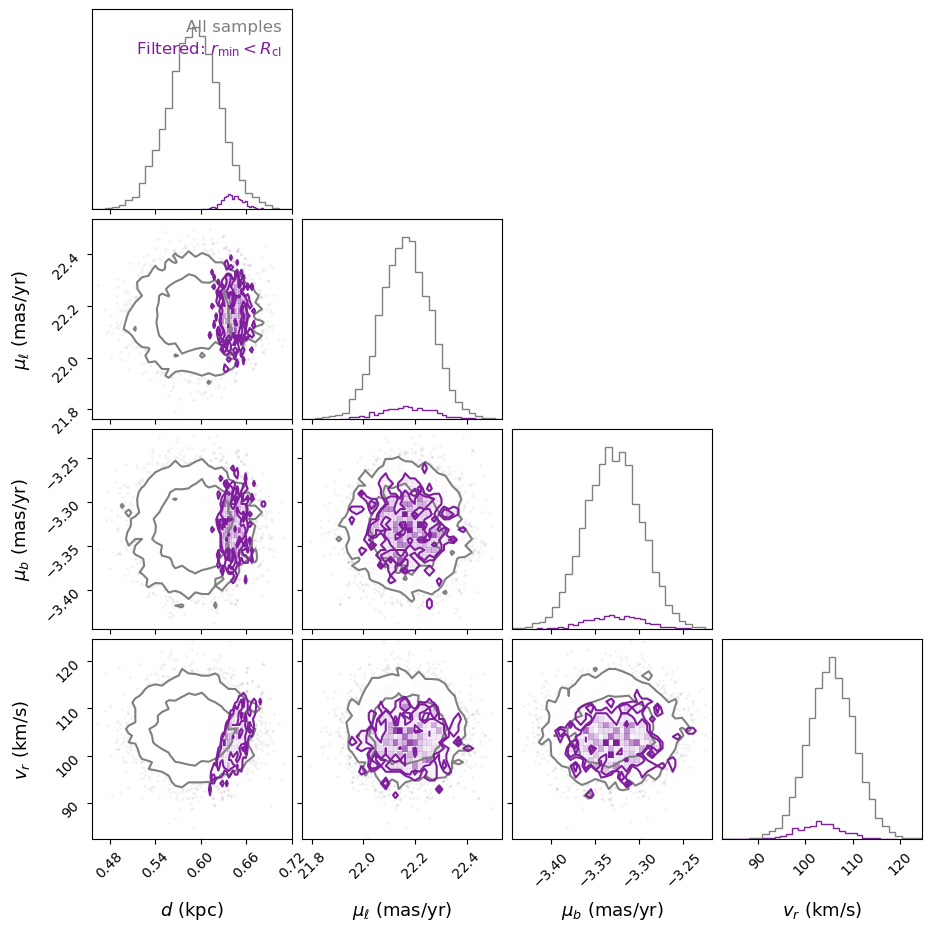

In [37]:
corner_with_filter(samples_x, blobs_x, 20)

# MCMC for AE Aur

In [38]:
AeAur

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,l,b,parallax,parallax_error,radial_velocity,radial_velocity_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,distance_bj,distance_bj_low,distance_bj_high,RV,RV_err,Name,Mod_SpType,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,l_err,b_err,pm_l_err,pm_b_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,deg,deg,mas,mas,km / s,km / s,,,,,,,,,,,kpc,kpc,kpc,km / s,km / s,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,str9,str11,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
182071570715713024,79.07559666990984,0.03253635,34.31251139077335,0.021343945,-4.74655801090574,0.04624765,43.53767238272993,0.03277261,172.08114110834472,-2.259140767320703,2.573988882528692,0.033972435,--,--,-0.14975126,-0.0010803483,-0.0281311,0.31334937,-0.10558603,0.39656842,-0.33576027,-0.05332556,0.2632448,-0.4346779,0.38020044000000003,0.3752654,0.38476196,56.7,0.6,AE Aur,xkcd:blue,0.3885020664959508,-38.28986996531914,21.258988393048448,8.526442869755808,239.913899974291,31.27369291617289,8.300215905982963,-4.020910377658974,9.116061647832543,-2.2629453641851103,-0.020125200123173502,-0.9618240607414603,91.9800631688847,48.54576241290892,-44.327140507117,25.300023970830598,104.0049184837074,0.005127590555753349,0.024861150656174388,0.012253224284901306,0.04070956157861264,0.020246659273163506


In [39]:
names_aeaur = ['AE Aur', 'Trapezium']
gpmc_args_aeaur = {'backend_name':'AE_AUR_trapezium_chain','star_params':AeAur,'cluster_params':Trapezium, 'cluster_radius':10,'int_time':-5.0,
            'names':names_aeaur}

In [40]:
#sample_ae, state_ae = gpMCMC().start_mcmc(**gpmc_args_aeaur)

In [41]:
backend_aeaur = emcee.backends.HDFBackend('AE_AUR_trapezium_chain.h5')

In [42]:
samples_aeaur = backend_aeaur.get_chain(thin=10, flat=True)
blobs_aeaur = backend_aeaur.get_blobs(thin=10,flat=True)
kinematic_ages_aeaur = np.array([b[0] for b in blobs_aeaur])
min_separations_aeaur = np.array([b[1] for b in blobs_aeaur])

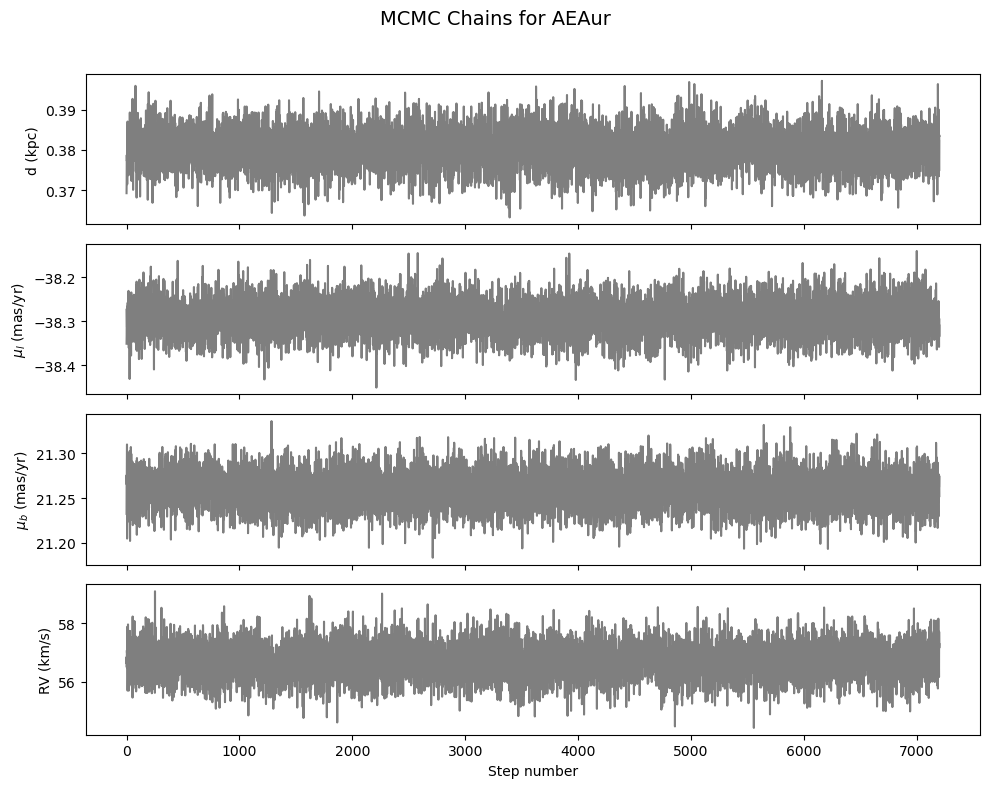

In [43]:

# Number of parameters
n_params = samples_aeaur.shape[1]
star_labels = ['d (kpc)', r'$\mu_l$ (mas/yr)', r'$\mu_b$ (mas/yr)', 'RV (km/s)']
# Create subplots
fig, axes = plt.subplots(n_params, figsize=(10, 2 * n_params), sharex=True)

# Plot each parameter's chain
for i in range(n_params):
    axes[i].plot(samples_aeaur[:, i], color="black", alpha=0.5)
    axes[i].set_ylabel(star_labels[i])

axes[-1].set_xlabel("Step number")
plt.suptitle("MCMC Chains for AEAur", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


7200
0


/home/karan/miniforge3/envs/GAIA_Query/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (1) than draws (0). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


AssertionError: I don't believe that you want more dimensions than samples!

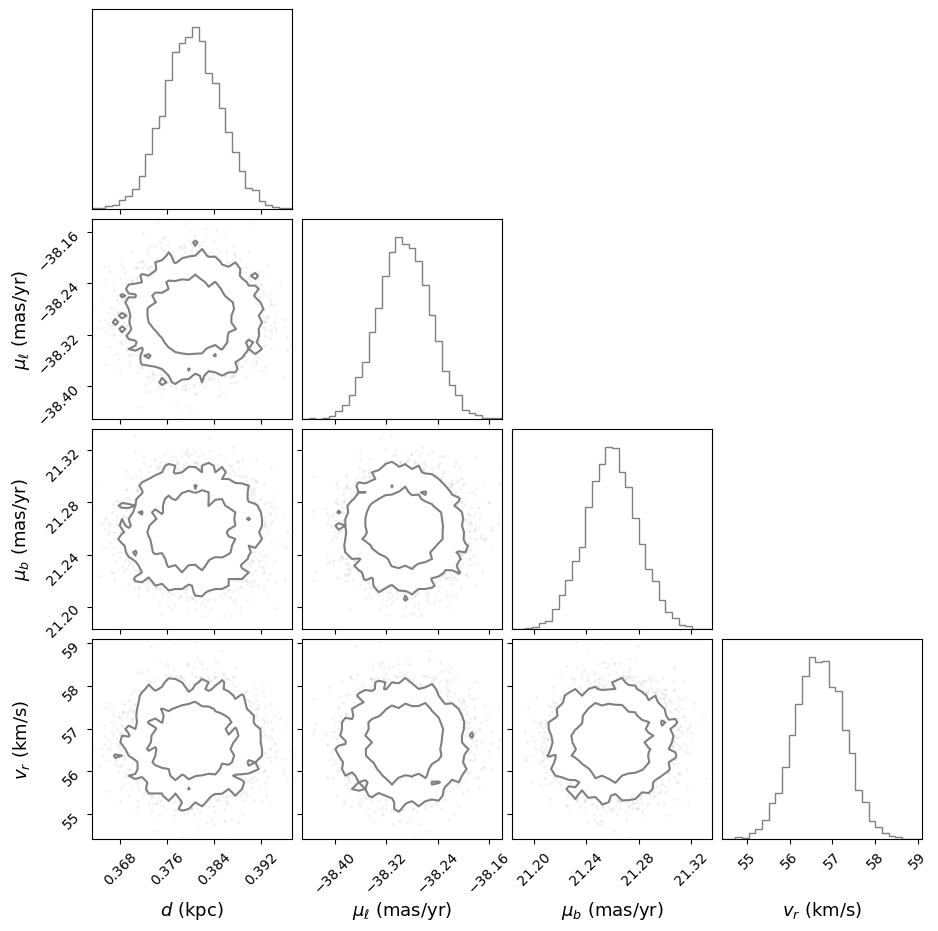

In [44]:
flat_blobs = np.column_stack([kinematic_ages_aeaur, min_separations_aeaur])
corner_with_filter(samples_aeaur, flat_blobs, 50)

In [ ]:

fig = corner.corner(kinematic_ages_aeaur[:, None], labels=["Kinematic_age"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)

In [ ]:
fig = corner.corner(min_separations[:,None], labels=["Min sep (pc)"],quantiles=(0.16,0.5, 0.84),show_titles=True,use_math_text=True,fill_contours=True)